PREPARE ENVIRONMENT:

In [1]:
# SET HYPERPARAMETERS   



In [2]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm  
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from scipy.stats import chi2
from xgboost import XGBClassifier

In [3]:
# LOAD DATA

df = pd.read_excel("data.xlsx")

pd.set_option("display.width", 200)

In [4]:
# PREDEFINE FUNCIONS

# MODEL EVALUATION
def classification_metrics(model, X_train, y_train, X_test, y_test, threshold=0.5):
    # Predicted probabilities
    train_proba = model.predict(X_train)
    test_proba = model.predict(X_test)
    # Convert probabilities to classes
    train_pred = (train_proba >= threshold).astype(int)
    test_pred = (test_proba >= threshold).astype(int)
    # Metrics
    metrics = {
        "Train": {
            "Accuracy": accuracy_score(y_train, train_pred),
            "Precision": precision_score(y_train, train_pred),
            "Recall": recall_score(y_train, train_pred),
            "F1": f1_score(y_train, train_pred),
            "AUC": roc_auc_score(y_train, train_proba),
            "Gini": 2 * roc_auc_score(y_train, train_proba) - 1
        },
        "Test": {
            "Accuracy": accuracy_score(y_test, test_pred),
            "Precision": precision_score(y_test, test_pred),
            "Recall": recall_score(y_test, test_pred),
            "F1": f1_score(y_test, test_pred),
            "AUC": roc_auc_score(y_test, test_proba),
            "Gini": 2 * roc_auc_score(y_test, test_proba) - 1
        }
    }
    return pd.DataFrame(metrics).T

# WoE
def calculate_woe_iv(df, feature, target="BAD"):
    table = df.groupby(feature, observed=True)[target].agg(
        total="count",
        bad="sum"
    )
    table["good"] = table["total"] - table["bad"]
    table["bad_rate"] = table["bad"] / table["total"]
    table["bad_dist"] = table["bad"] / table["bad"].sum()
    table["good_dist"] = table["good"] / table["good"].sum()
    table["WoE"] = np.log(table["good_dist"] / table["bad_dist"])
    table["IV"] = (
        (table["good_dist"] - table["bad_dist"])
        * table["WoE"]
    )
    total = pd.DataFrame({
        "total": [table["total"].sum()],
        "bad": [table["bad"].sum()],
        "good": [table["good"].sum()],
        "bad_dist": [table["bad_dist"].sum()],
        "good_dist": [table["good_dist"].sum()],
        "WoE": [np.nan],
        "IV": [table["IV"].sum()]
    }, index=["Total"])

    return pd.concat([table, total])

EXPLORATORY DATA ANALYSIS:

In [5]:
# INSPECT DATA

print(df)
print(df.isna().sum())
print(df.describe())
print(df.dtypes)
print(df["REASON"].value_counts())
print(df["JOB"].value_counts())


      BAD   LOAN  MORTDUE     VALUE   REASON     JOB   YOJ  DEROG  DELINQ       CLAGE  NINQ  CLNO    DEBTINC
0       1   1100  25860.0   39025.0  HomeImp   Other  10.5    0.0     0.0   94.366667   1.0   9.0        NaN
1       1   1300  70053.0   68400.0  HomeImp   Other   7.0    0.0     2.0  121.833333   0.0  14.0        NaN
2       1   1500  13500.0   16700.0  HomeImp   Other   4.0    0.0     0.0  149.466667   1.0  10.0        NaN
3       1   1500      NaN       NaN      NaN     NaN   NaN    NaN     NaN         NaN   NaN   NaN        NaN
4       0   1700  97800.0  112000.0  HomeImp  Office   3.0    0.0     0.0   93.333333   0.0  14.0        NaN
...   ...    ...      ...       ...      ...     ...   ...    ...     ...         ...   ...   ...        ...
5955    0  88900  57264.0   90185.0  DebtCon   Other  16.0    0.0     0.0  221.808718   0.0  16.0  36.112347
5956    0  89000  54576.0   92937.0  DebtCon   Other  16.0    0.0     0.0  208.692070   0.0  15.0  35.859971
5957    0  89200  5

In [6]:
print(df.head())

   BAD  LOAN  MORTDUE     VALUE   REASON     JOB   YOJ  DEROG  DELINQ       CLAGE  NINQ  CLNO  DEBTINC
0    1  1100  25860.0   39025.0  HomeImp   Other  10.5    0.0     0.0   94.366667   1.0   9.0      NaN
1    1  1300  70053.0   68400.0  HomeImp   Other   7.0    0.0     2.0  121.833333   0.0  14.0      NaN
2    1  1500  13500.0   16700.0  HomeImp   Other   4.0    0.0     0.0  149.466667   1.0  10.0      NaN
3    1  1500      NaN       NaN      NaN     NaN   NaN    NaN     NaN         NaN   NaN   NaN      NaN
4    0  1700  97800.0  112000.0  HomeImp  Office   3.0    0.0     0.0   93.333333   0.0  14.0      NaN


UNIVARIATE ANALYSIS OF EXPLORATORY VARIABLES:

In [7]:
# TRAIN TEST SPLIT  

train, test = train_test_split(df, test_size=0.30,random_state=42,stratify=df["BAD"])
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)
# Check stratification
print(train["BAD"].value_counts(normalize=True))
print(test["BAD"].value_counts(normalize=True))
# Make a copy for baseline model
train_base = train.copy()
test_base = test.copy()



BAD
0    0.800575
1    0.199425
Name: proportion, dtype: float64
BAD
0    0.800336
1    0.199664
Name: proportion, dtype: float64


In [8]:

# INSPECT WHETHER NaN ITSELF CONTAINS INFORMATION ABOUT THE DEFAULT
for col in train.columns:
    if train[col].isna().any():
        print(f"\n--- {col} ---")
        print(
            train.groupby(train[col].isna())["BAD"]
            .agg(count="count", bad_rate="mean")
        )
# Huge significancy in VALUE, DEBTINC



--- MORTDUE ---
         count  bad_rate
MORTDUE                 
False     3805  0.197635
True       367  0.217984

--- VALUE ---
       count  bad_rate
VALUE                 
False   4098  0.186432
True      74  0.918919

--- REASON ---
        count  bad_rate
REASON                 
False    4008  0.200599
True      164  0.170732

--- JOB ---
       count  bad_rate
JOB                   
False   3972  0.205942
True     200  0.070000

--- YOJ ---
       count  bad_rate
YOJ                   
False   3826  0.204914
True     346  0.138728

--- DEROG ---
       count  bad_rate
DEROG                 
False   3672  0.209423
True     500  0.126000

--- DELINQ ---
        count  bad_rate
DELINQ                 
False    3770  0.206366
True      402  0.134328

--- CLAGE ---
       count  bad_rate
CLAGE                 
False   3950  0.195443
True     222  0.270270

--- NINQ ---
       count  bad_rate
NINQ                  
False   3828  0.203239
True     344  0.156977

--- CLNO ---
       c

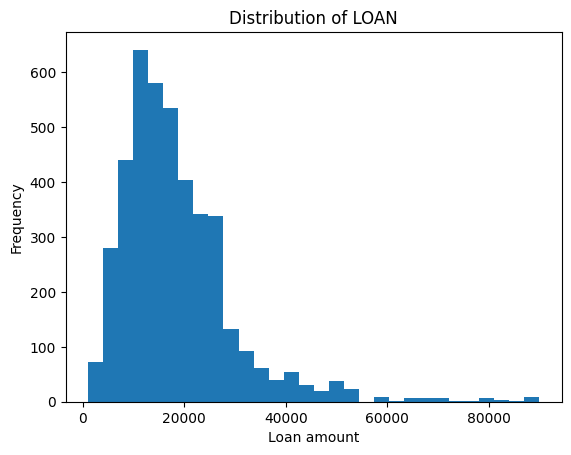

Optimization terminated successfully.
         Current function value: 0.494887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                          Logit   Df Residuals:                     4170
Method:                           MLE   Df Model:                            1
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                0.009441
Time:                        17:59:43   Log-Likelihood:                -2064.7
converged:                       True   LL-Null:                       -2084.3
Covariance Type:            nonrobust   LLR p-value:                 3.533e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9586      0.080    -11.991      0.000      -1.115      -0.802
LOAN       -2.446e-05   4.15e

In [9]:
# LOAN

# INSPECT DISTRIBUTION
plt.hist(train["LOAN"], bins=30)
plt.xlabel("Loan amount")
plt.ylabel("Frequency")
plt.title("Distribution of LOAN")
plt.show()

# UNIVARIATE LOGISTIC REGRESSION
c_loan = train.loc[train["LOAN"] > 0, "LOAN"].min() / 2
train["LOAN_LOG"] = np.log(train["LOAN"] + c_loan)
X = sm.add_constant(train[["LOAN"]])
y = train["BAD"]
model = sm.Logit(y, X).fit()
print(model.summary())
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of LOAN coefficient: {model.pvalues['LOAN']}")
model = sm.Logit(y, np.log(X+c_loan)).fit()
print(model.summary())
print(f"Constanct c: {c_loan}")
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of LOAN coefficient: {model.pvalues['LOAN']}")
# APPLY SAME TRANSFORMATION ON TEST SET
test["LOAN_LOG"] = np.log(test["LOAN"] + c_loan)

# Continous variable where we do not want to bin, cannot use WoE or IV, we fit univariate logistic regression and inspect pseudo R squared and p-value
# Log transformation of explanatory variable; log(x+c) where c =: min(x;x>0) /2; 


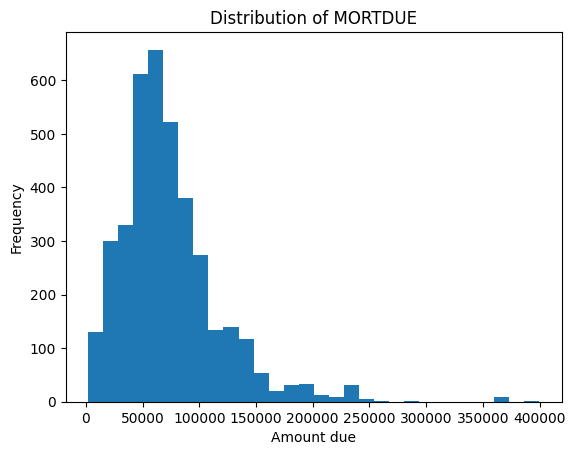

Optimization terminated successfully.
         Current function value: 0.497209
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                          Logit   Df Residuals:                     4170
Method:                           MLE   Df Model:                            1
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                0.004794
Time:                        17:59:44   Log-Likelihood:                -2074.4
converged:                       True   LL-Null:                       -2084.3
Covariance Type:            nonrobust   LLR p-value:                 7.802e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0750      0.081    -13.282      0.000      -1.234      -0.916
MORTDUE    -4.396e-06   1.02e

In [10]:
# MORTDUE

# INSPECT DISTRIBUTION
plt.hist(train["MORTDUE"], bins=30)
plt.xlabel("Amount due")
plt.ylabel("Frequency")
plt.title("Distribution of MORTDUE")
plt.show()

# INPUTE MISSING VALUES BY MEAN
mortdue_mean = train["MORTDUE"].mean()
train["MORTDUE"] = train["MORTDUE"].fillna(mortdue_mean)


# UNIVARIATE LOGISTIC REGRESSION
c_mort = train.loc[train["MORTDUE"] > 0, "MORTDUE"].min() / 2
train["MORTDUE_LOG"] = np.log(train["MORTDUE"] + c_mort)
X = sm.add_constant(train[["MORTDUE"]])
y = train["BAD"]
model = sm.Logit(y, X).fit()
print(model.summary())
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of MORTDUE coefficient: {model.pvalues['MORTDUE']}")
model = sm.Logit(y, np.log(X+c_mort)).fit()
print(model.summary())
print(f"Constanct c: {c_mort}")
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of MORTDUE coefficient: {model.pvalues['MORTDUE']}")

# APPLY SAME OPERATIONS ON TEST DATA
test["MORTDUE"] = test["MORTDUE"].fillna(mortdue_mean)
test["MORTDUE_LOG"] = np.log(test["MORTDUE"] + c_mort)

# Continous variable where we do not want to bin, cannot use WoE or IV, we fit univariate logistic regression and inspect pseudo R squared and p-value
# Log transformation of explanatory variable; log(x+c) where c =: min(x;x>0) /2; 


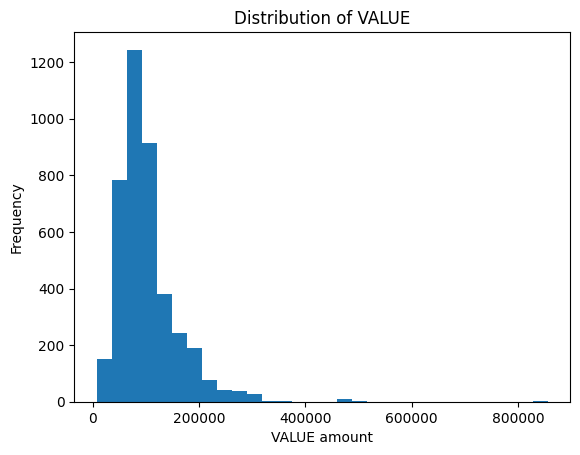

                      total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
(7999.999, 49421.9]     410  135   275  0.329268  0.176702   0.082484 -0.761864  0.071781
(49421.9, 61944.6]      410   82   328  0.200000  0.107330   0.098380 -0.087066  0.000779
(61944.6, 70811.5]      410   72   338  0.175610  0.094241   0.101380  0.073020  0.000521
(70811.5, 80400.0]      410   87   323  0.212195  0.113874   0.096881 -0.161616  0.002746
(80400.0, 89749.0]      409   70   339  0.171149  0.091623   0.101680  0.104145  0.001047
(89749.0, 99824.2]      410   47   363  0.114634  0.061518   0.108878  0.570895  0.027038
(99824.2, 113011.2]     409   67   342  0.163814  0.087696   0.102579  0.156758  0.002333
(113011.2, 131945.4]    410   64   346  0.156098  0.083770   0.103779  0.214195  0.004286
(131945.4, 175254.5]    410   83   327  0.202439  0.108639   0.098080 -0.102241  0.001079
(175254.5, 855909.0]    410   57   353  0.139024  0.074607   0.105879  0.350057  0.010947
Total     

In [11]:
# VALUE

# INSPECT DISTRIBUTION
plt.hist(train["VALUE"], bins=30)
plt.xlabel("VALUE amount")
plt.ylabel("Frequency")
plt.title("Distribution of VALUE")
plt.show()

# INSPECT DISTRIBUTION OF BAD AMONGST 10 QUANTILE BINS
train["VALUE_BIN"] = pd.qcut(
    train["VALUE"],
    q=10,
    duplicates="drop"
)
print(calculate_woe_iv(train, "VALUE_BIN", "BAD"))

# CREATE MEANINFGUL BINS
bins = [0, 50_000, np.inf]
labels = ["<50k",">50k"]
train["VALUE_BIN"] = pd.cut(
    train["VALUE"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
train["VALUE_BIN"] = train["VALUE_BIN"].cat.add_categories("Missing")
train["VALUE_BIN"] = train["VALUE_BIN"].fillna("Missing")
print(calculate_woe_iv(train, "VALUE_BIN", "BAD"))

# APPLY SAME OPERATIONS ON TEST DATA
test["VALUE_BIN"] = pd.cut(
    test["VALUE"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
test["VALUE_BIN"] = test["VALUE_BIN"].cat.add_categories("Missing")
test["VALUE_BIN"] = test["VALUE_BIN"].fillna("Missing")
# Missing values important discriminant here, hence we want to bin this continous variable.

In [12]:
# REASON

# INSPECT DISTRIBUTION
table = pd.crosstab(
    train["REASON"].fillna("Missing"),
    train["BAD"]
)
table["bad_rate"] = table[1] / table.sum(axis=1)
print(table)

# CREATE MEANINGFUL BINS
train["REASON_BIN"] = train["REASON"].fillna("Missing")
print(calculate_woe_iv(train, "REASON_BIN"))
train["REASON_BIN"] = train["REASON"].fillna("HomeImp")
print(calculate_woe_iv(train, "REASON_BIN"))
train["REASON_BIN"] = train["REASON"].fillna("DebtCon")
print(calculate_woe_iv(train, "REASON_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["REASON_BIN"] = test["REASON"].fillna("DebtCon")

BAD         0    1  bad_rate
REASON                      
DebtCon  2216  518  0.189466
HomeImp   988  286  0.224490
Missing   136   28  0.170732
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
DebtCon   2734  518  2216  0.189466  0.622596   0.663473  0.063590  0.002599
HomeImp   1274  286   988  0.224490  0.343750   0.295808 -0.150203  0.007201
Missing    164   28   136  0.170732  0.033654   0.040719  0.190557  0.001346
Total     4172  832  3340       NaN  1.000000   1.000000       NaN  0.011147
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
DebtCon   2734  518  2216  0.189466  0.622596   0.663473  0.063590  0.002599
HomeImp   1438  314  1124  0.218359  0.377404   0.336527 -0.114638  0.004686
Total     4172  832  3340       NaN  1.000000   1.000000       NaN  0.007285
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
DebtCon   2898  546  2352  0.188406   0.65625   0.704192  0.070509  0.003380
HomeImp 

In [13]:
# JOB

# INSPECT DISTRIBUTION
job_table = train.groupby("JOB", dropna=False)["BAD"].agg(
    count="count",
    bad_rate="mean"
)
print(job_table)

# CREATE MEANINGFUL BINS
train["JOB_BIN"] = train["JOB"].fillna("Missing")
print(calculate_woe_iv(train, "JOB_BIN"))
train["JOB_BIN"] = train["JOB"].replace({
    "Mgr": "Leadership/Professional",
    "ProfExe": "Leadership/Professional",
    "Sales": "Performance-based",
    "Self": "Performance-based"
})
train["JOB_BIN"] = train["JOB_BIN"].fillna("Missing")
print(calculate_woe_iv(train, "JOB_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["JOB_BIN"] = test["JOB"].replace({
    "Mgr": "Leadership/Professional",
    "ProfExe": "Leadership/Professional",
    "Sales": "Performance-based",
    "Self": "Performance-based"
})
test["JOB_BIN"] = test["JOB_BIN"].fillna("Missing")


         count  bad_rate
JOB                     
Mgr        531  0.233522
Office     663  0.126697
Other     1680  0.232143
ProfExe    890  0.169663
Sales       77  0.389610
Self       131  0.297710
NaN        200  0.070000
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
Mgr        531  124   407  0.233522  0.149038   0.121856 -0.201362  0.005473
Missing    200   14   186  0.070000  0.016827   0.055689  1.196796  0.046510
Office     663   84   579  0.126697  0.100962   0.173353  0.540592  0.039134
Other     1680  390  1290  0.232143  0.468750   0.386228 -0.193643  0.015980
ProfExe    890  151   739  0.169663  0.181490   0.221257  0.198124  0.007879
Sales       77   30    47  0.389610  0.036058   0.014072 -0.940943  0.020687
Self       131   39    92  0.297710  0.046875   0.027545 -0.531667  0.010277
Total     4172  832  3340       NaN  1.000000   1.000000       NaN  0.145941
                         total  bad  good  bad_rate  bad_dist  good_dist       WoE

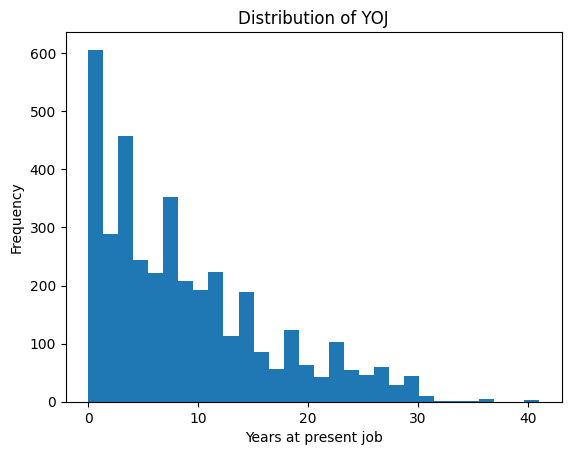

               total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
(-0.001, 1.0]    606  129   477  0.212871  0.155048   0.142814 -0.082190  0.001005
(1.0, 2.0]       277   70   207  0.252708  0.084135   0.061976 -0.305670  0.006773
(2.0, 4.0]       468  113   355  0.241453  0.135817   0.106287 -0.245164  0.007240
(4.0, 5.0]       243   62   181  0.255144  0.074519   0.054192 -0.318531  0.006475
(5.0, 7.0]       398   62   336  0.155779  0.074519   0.100599  0.300083  0.007826
(7.0, 9.0]       381   66   315  0.173228  0.079327   0.094311  0.173024  0.002593
(9.0, 11.0]      319   74   245  0.231975  0.088942   0.073353 -0.192701  0.003004
(11.0, 15.0]     404   88   316  0.217822  0.105769   0.094611 -0.111488  0.001244
(15.0, 21.0]     373   72   301  0.193029  0.086538   0.090120  0.040551  0.000145
(21.0, 41.0]     357   48   309  0.134454  0.057692   0.092515  0.472247  0.016445
Missing          346   48   298  0.138728  0.057692   0.089222  0.435999  0.013747
Tota

In [14]:
# YOJ

# INSPECT DISTRIBUTION
plt.hist(train["YOJ"].dropna(), bins=30)
plt.xlabel("Years at present job")
plt.ylabel("Frequency")
plt.title("Distribution of YOJ")
plt.show()

# CREATE MEANINGFUL BINS
# 10 quantile bins
train["YOJ_BIN"] = pd.qcut(
    train["YOJ"],
    q=10,
    duplicates="drop"
)
train["YOJ_BIN"] = train["YOJ_BIN"].astype("object").fillna("Missing")
print(calculate_woe_iv(train, "YOJ_BIN"))
# Manual bins
bins = [0, 5, 20, np.inf]
labels = ["0-5","5-20", "20+"]
train["YOJ_BIN"] = pd.cut(
    train["YOJ"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
train["YOJ_BIN"] = (
    train["YOJ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "YOJ_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["YOJ_BIN"] = pd.cut(
    train["YOJ"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
test["YOJ_BIN"] = (
    test["YOJ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)

In [15]:
# DEROG

# INSPECT DISTRIBUTION
derog_table = train.groupby("DEROG", dropna=False)["BAD"].agg(
    count="count",
    bad_rate="mean"
)
print(derog_table)

# CREATE MEANINGFUL BINS
bins = [-np.inf, 0, 1, 2, 3, 4, 5, np.inf]
labels = ["0", "1", "2", "3", "4", "5", "6+"]
train["DEROG_BIN"] = pd.cut(
    train["DEROG"],
    bins=bins,
    labels=labels
)
train["DEROG_BIN"] = (
    train["DEROG_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "DEROG_BIN"))
# MANUAL BINS
bins = [-np.inf, 0, 2, np.inf]
labels = ["0", "1-2", "3+"]
train["DEROG_BIN"] = pd.cut(
    train["DEROG"],
    bins=bins,
    labels=labels
)
train["DEROG_BIN"] = (
    train["DEROG_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "DEROG_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["DEROG_BIN"] = pd.cut(
    test["DEROG"],
    bins=bins,
    labels=labels
)
test["DEROG_BIN"] = (
    test["DEROG_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)


       count  bad_rate
DEROG                 
0.0     3164  0.165297
1.0      295  0.393220
2.0      118  0.500000
3.0       41  0.707317
4.0       17  0.764706
5.0       11  0.545455
6.0       11  0.727273
7.0        7  1.000000
8.0        4  1.000000
9.0        2  1.000000
10.0       2  1.000000
NaN      500  0.126000
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
0         3164  523  2641  0.165297  0.628606   0.790719  0.229438  0.037195
1          295  116   179  0.393220  0.139423   0.053593 -0.956098  0.082062
2          118   59    59  0.500000  0.070913   0.017665 -1.389894  0.074010
3           41   29    12  0.707317  0.034856   0.003593 -2.272283  0.071038
4           17   13     4  0.764706  0.015625   0.001198 -2.568549  0.037057
5           11    6     5  0.545455  0.007212   0.001497 -1.572215  0.008984
6+          26   23     3  0.884615  0.027644   0.000898 -3.426776  0.091653
Missing    500   63   437  0.126000  0.075721   0.130838  0.54

In [16]:
# DELINQ

# INSPECT DISTRIBUTION
delinq_table = train.groupby("DELINQ", dropna=False)["BAD"].agg(
    count="count",
    bad_rate="mean"
)
print(delinq_table)

# CREATE MEANINGFUL BINS
bins = [-np.inf, 0, 1, 2, 3, 4, np.inf]
labels = ["0", "1", "2", "3", "4", "5+"]
train["DELINQ_BIN"] = pd.cut(
    train["DELINQ"],
    bins=bins,
    labels=labels
)
train["DELINQ_BIN"] = (
    train["DELINQ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "DELINQ_BIN"))
# MANUAL BINS
bins = [-np.inf, 0, 4, np.inf]
labels = ["0", "1-4", "5+"]
train["DELINQ_BIN"] = pd.cut(
    train["DELINQ"],
    bins=bins,
    labels=labels
)
train["DELINQ_BIN"] = (
    train["DELINQ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "DELINQ_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["DELINQ_BIN"] = pd.cut(
    test["DELINQ"],
    bins=bins,
    labels=labels
)
test["DELINQ_BIN"] = (
    test["DELINQ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)


        count  bad_rate
DELINQ                 
0.0      2922  0.139288
1.0       462  0.324675
2.0       177  0.463277
3.0        86  0.534884
4.0        57  0.561404
5.0        30  0.833333
6.0        17  1.000000
7.0         9  1.000000
8.0         3  1.000000
10.0        2  1.000000
11.0        2  1.000000
12.0        1  1.000000
13.0        1  1.000000
15.0        1  1.000000
NaN       402  0.134328
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
0         2922  407  2515  0.139288  0.489183   0.752994  0.431321  0.113787
1          462  150   312  0.324675  0.180288   0.093413 -0.657526  0.057123
2          177   82    95  0.463277  0.098558   0.028443 -1.242736  0.087134
3           86   46    40  0.534884  0.055288   0.011976 -1.529656  0.066253
4           57   32    25  0.561404  0.038462   0.007485 -1.636754  0.050701
5+          66   61     5  0.924242  0.073317   0.001497 -3.891330  0.279476
Missing    402   54   348  0.134328  0.064904   0.104

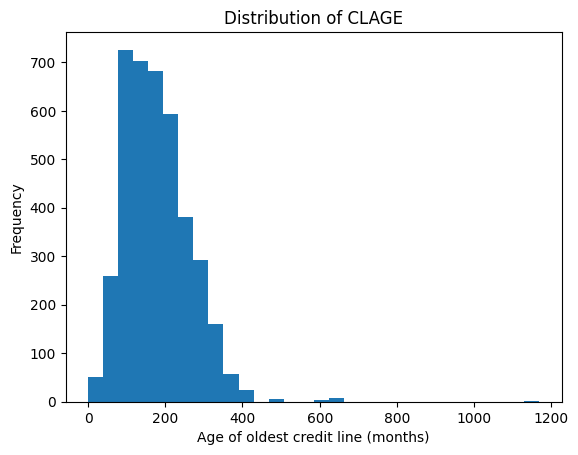

Optimization terminated successfully.
         Current function value: 0.484738
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                          Logit   Df Residuals:                     4170
Method:                           MLE   Df Model:                            1
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                 0.02976
Time:                        17:59:45   Log-Likelihood:                -2022.3
converged:                       True   LL-Null:                       -2084.3
Covariance Type:            nonrobust   LLR p-value:                 8.236e-29
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4065      0.096     -4.224      0.000      -0.595      -0.218
CLAGE         -0.0059      0.

In [17]:
# CLAGE

# INSPECT DISTRIBUTION
plt.hist(train["CLAGE"].dropna(), bins=30)
plt.xlabel("Age of oldest credit line (months)")
plt.ylabel("Frequency")
plt.title("Distribution of CLAGE")
plt.show()

# INPUTE MISSING VALUES BY MEAN
clage_mean = train["CLAGE"].mean()
train["CLAGE"] = train["CLAGE"].fillna(clage_mean)

# UNIVARIATE LOGISTIC REGRESSION
c_clage = train.loc[train["CLAGE"] > 0, "CLAGE"].min() / 2
train["CLAGE_LOG"] = np.log(train["CLAGE"] + c_clage)
X = sm.add_constant(train[["CLAGE"]])
y = train["BAD"]
model = sm.Logit(y, X).fit()
print(model.summary())
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of CLAGE coefficient: {model.pvalues['CLAGE']}")
model = sm.Logit(y, np.log(X+c_clage)).fit()
print(model.summary())
print(f"Constanct c: {c_clage}")
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of CLAGE coefficient: {model.pvalues['CLAGE']}")

# APPLY SAME OPERATIONS ON TEST DATA
test["CLAGE"] = test["CLAGE"].fillna(clage_mean)
test["CLAGE_LOG"] = np.log(test["CLAGE"] + c_clage)

# Continous variable where we do not want to bin, cannot use WoE or IV, we fit univariate logistic regression and inspect pseudo R squared and p-value
# Log transformation of explanatory variable; log(x+c) where c =: min(x;x>0) /2; 




In [18]:
# NINQ

# INSPECT DISTRIBUTION
ninq_table = train.groupby("NINQ", dropna=False)["BAD"].agg(
    count="count",
    bad_rate="mean"
)
print(ninq_table)

# CREATE MEANINGFUL BINS
bins = [-np.inf, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, np.inf]
labels = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11+"]
train["NINQ_BIN"] = pd.cut(
    train["NINQ"],
    bins=bins,
    labels=labels
)
train["NINQ_BIN"] = (
    train["NINQ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "NINQ_BIN"))
# MANUAL BINS
bins = [-np.inf, 0, 3, np.inf]
labels = ["0", "1-3", "3+"]
train["NINQ_BIN"] = pd.cut(
    train["NINQ"],
    bins=bins,
    labels=labels
)
train["NINQ_BIN"] = (
    train["NINQ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "NINQ_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["NINQ_BIN"] = pd.cut(
    test["NINQ"],
    bins=bins,
    labels=labels
)
test["NINQ_BIN"] = (
    test["NINQ_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)

      count  bad_rate
NINQ                 
0.0    1760  0.158523
1.0     940  0.184043
2.0     560  0.233929
3.0     286  0.279720
4.0     111  0.351351
5.0      49  0.469388
6.0      39  0.538462
7.0      29  0.344828
8.0      16  0.437500
9.0       6  0.500000
10.0     20  0.250000
11.0      8  0.375000
12.0      1  1.000000
13.0      2  1.000000
17.0      1  1.000000
NaN     344  0.156977
         total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
0         1760  279  1481  0.158523  0.335337   0.443413  0.279367  0.030193
1          940  173   767  0.184043  0.207933   0.229641  0.099302  0.002156
2          560  131   429  0.233929  0.157452   0.128443 -0.203634  0.005907
3          286   80   206  0.279720  0.096154   0.061677 -0.444044  0.015309
4          111   39    72  0.351351  0.046875   0.021557 -0.776789  0.019667
5           49   23    26  0.469388  0.027644   0.007784 -1.267291  0.025168
6           39   21    18  0.538462  0.025240   0.005389 -1.54404

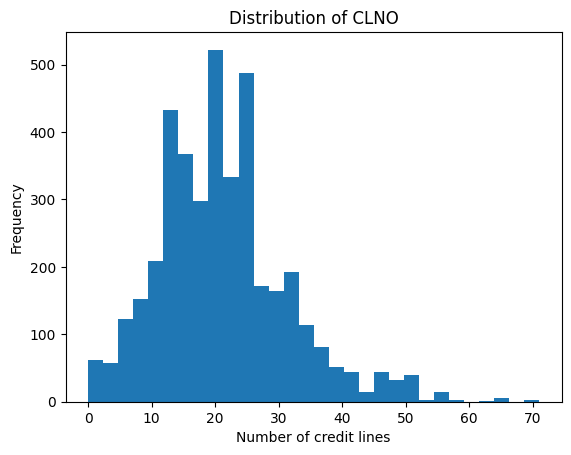

Optimization terminated successfully.
         Current function value: 0.499558
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                          Logit   Df Residuals:                     4170
Method:                           MLE   Df Model:                            1
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:               9.121e-05
Time:                        17:59:45   Log-Likelihood:                -2084.2
converged:                       True   LL-Null:                       -2084.3
Covariance Type:            nonrobust   LLR p-value:                    0.5375
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3393      0.091    -14.783      0.000      -1.517      -1.162
CLNO          -0.0024      0.

In [19]:
# CLNO

# INSPECT DISTRIBUTION
plt.hist(train["CLNO"].dropna(), bins=30)
plt.xlabel("Number of credit lines")
plt.ylabel("Frequency")
plt.title("Distribution of CLNO")
plt.show()

# INPUTE MISSING VALUES BY MEAN
clno_mean = train["CLNO"].mean()
train["CLNO"] = train["CLNO"].fillna(clno_mean)

# UNIVARIATE LOGISTIC REGRESSION
c_clno = train.loc[train["CLNO"] > 0, "CLNO"].min() / 2
train["CLNO_LOG"] = np.log(train["CLNO"] + c_clno)
X = sm.add_constant(train[["CLNO"]])
y = train["BAD"]
model = sm.Logit(y, X).fit()
print(model.summary())
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of CLNO coefficient: {model.pvalues['CLNO']}")
model = sm.Logit(y, np.log(X+c_clno)).fit()
print(model.summary())
print(f"Constanct c: {c_clno}")
print(f"Pseudo R squared: {model.prsquared}")
print(f"P-value of CLNO coefficient: {model.pvalues['CLNO']}")

# APPLY SAME OPERATIONS ON TEST DATA
test["CLNO"] = test["CLNO"].fillna(clno_mean)
test["CLNO_LOG"] = np.log(test["CLNO"] + c_clno)
# Continous variable where we do not want to bin, cannot use WoE or IV, we fit univariate logistic regression and inspect pseudo R squared and p-value
# Log transformation of explanatory variable; log(x+c) where c =: min(x;x>0) /2; 


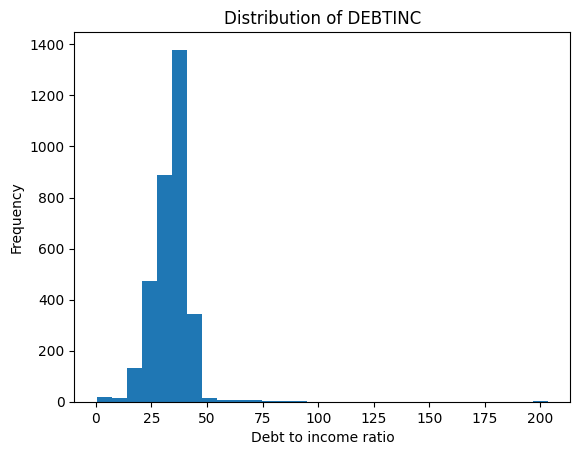

                   total  bad  good  bad_rate  bad_dist  good_dist       WoE        IV
(0.523, 23.887]      330   26   304  0.078788  0.031250   0.091018  1.069038  0.063894
(23.887, 27.693]     329   15   314  0.045593  0.018029   0.094012  1.651449  0.125482
(27.693, 30.327]     329   10   319  0.030395  0.012019   0.095509  2.072712  0.173050
(30.327, 32.862]     329   21   308  0.063830  0.025240   0.092216  1.295684  0.086779
(32.862, 34.868]     329   17   312  0.051672  0.020433   0.093413  1.519896  0.110923
(34.868, 36.572]     329   29   300  0.088146  0.034856   0.089820  0.946593  0.052029
(36.572, 38.188]     329   24   305  0.072948  0.028846   0.091317  1.152364  0.071990
(38.188, 39.799]     329   21   308  0.063830  0.025240   0.092216  1.295684  0.086779
(39.799, 41.428]     329   29   300  0.088146  0.034856   0.089820  0.946593  0.052029
(41.428, 203.312]    330   90   240  0.272727  0.108173   0.071856 -0.409064  0.014856
Missing              880  550   330  0.6250

In [20]:
# DEBTINC

# INSPECT DISTRIBUTION
plt.hist(train["DEBTINC"].dropna(), bins=30)
plt.xlabel("Debt to income ratio")
plt.ylabel("Frequency")
plt.title("Distribution of DEBTINC")
plt.show()

# CREATE MEANINGFUL BINS
train["DEBTINC_BIN"] = pd.qcut(
    train["DEBTINC"],
    q=10,
    duplicates="drop"
)
train["DEBTINC_BIN"] = (
    train["DEBTINC_BIN"]
    .astype("object")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "DEBTINC_BIN"))
# MANUAL BINS
bins = [-np.inf, 40, np.inf]
labels = ["<40", "40+"]
train["DEBTINC_BIN"] = pd.cut(
    train["DEBTINC"],
    bins=bins,
    labels=labels
)
train["DEBTINC_BIN"] = (
    train["DEBTINC_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
print(calculate_woe_iv(train, "DEBTINC_BIN"))

# APPLY SAME OPERATIONS ON TEST DATA
test["DEBTINC_BIN"] = pd.cut(
    test["DEBTINC"],
    bins=bins,
    labels=labels
)
test["DEBTINC_BIN"] = (
    test["DEBTINC_BIN"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)

MODEL BUILDING:

In [21]:
# BASELINE MODEL - SIMPLE IMPUTATION OF NaNs, NO TRANSFORMATION, NO BINNING

# PREPARE DATA
# Continuous variables
continuous_cols = [
    "LOAN",
    "MORTDUE",
    "VALUE",
    "YOJ",
    "DEROG",
    "DELINQ",
    "CLAGE",
    "NINQ",
    "CLNO",
    "DEBTINC"
]
# Categorical variables
categorical_cols = [
    "REASON",
    "JOB"
]
# IMPUTE CONTINUOUS VARIABLES WITH TRAIN MEAN
for col in continuous_cols:
    mean_value = train[col].mean()
    train_base[col] = train[col].fillna(mean_value)
    test_base[col] = test[col].fillna(mean_value)
# IMPUTE CATEGORICAL VARIABLES WITH TRAIN MODE
for col in categorical_cols:
    mode_value = train[col].mode()[0]
    train_base[col] = train[col].fillna(mode_value)
    test_base[col] = test[col].fillna(mode_value)
# Check
"""
print(train[continuous_cols + categorical_cols].isna().sum())
print(test[continuous_cols + categorical_cols].isna().sum())
"""
# PREPARE CATEGORICAL VARIABLES
train_baseline = pd.get_dummies(
    train_base[continuous_cols + categorical_cols],
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
test_baseline = pd.get_dummies(
    test_base[continuous_cols + categorical_cols],
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
# Make sure train and test have exactly the same columns
test_baseline = test_baseline.reindex(
    columns=train_baseline.columns,
    fill_value=0
)
# FIT MODEL
X_train = sm.add_constant(train_baseline)
y_train = train_base["BAD"]
baseline_model = sm.Logit(y_train, X_train).fit()
# PREPARE TEST DATA
X_test = sm.add_constant(test_baseline)
y_test = test_base["BAD"]
# EVALUATE BASELINE MODEL
baseline_metrics = classification_metrics(
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5
)
print(baseline_metrics)



Optimization terminated successfully.
         Current function value: 0.388462
         Iterations 7
       Accuracy  Precision    Recall       F1       AUC      Gini
Train  0.837728   0.715877  0.308894  0.43157  0.807081  0.614162
Test   0.835011   0.693750  0.310924  0.42940  0.771917  0.543834


In [22]:
# ADJUSTED MODEL — BINNED VARIABLES + CATEGORICAL VARIABLES
# NO IMPUTATION

adjusted_cols = [
    "LOAN_LOG",
    "MORTDUE_LOG",
    "VALUE_BIN",
    "REASON",
    "JOB_BIN",
    "YOJ_BIN",
    "DEROG_BIN",
    "DELINQ_BIN",
    "CLAGE_LOG",
    "NINQ_BIN",
    "CLNO_LOG",
    "DEBTINC_BIN"
]
# CATEGORICAL / BINNED VARIABLES
adjusted_categorical_cols = [
    "VALUE_BIN",
    "REASON",
    "JOB_BIN",
    "YOJ_BIN",
    "DEROG_BIN",
    "DELINQ_BIN",
    "NINQ_BIN",
    "DEBTINC_BIN"
]
# PREPARE TRAIN DATA
train_adjusted = pd.get_dummies(
    train[adjusted_cols],
    columns=adjusted_categorical_cols,
    drop_first=True,
    dtype=int
)
# PREPARE TEST DATA
test_adjusted = pd.get_dummies(
    test[adjusted_cols],
    columns=adjusted_categorical_cols,
    drop_first=True,
    dtype=int
)
# MAKE SURE TRAIN AND TEST HAVE EXACTLY THE SAME COLUMNS
test_adjusted = test_adjusted.reindex(
    columns=train_adjusted.columns,
    fill_value=0
)
# FIT MODEL
X_train_adj = sm.add_constant(train_adjusted)
y_train = train["BAD"]
adjusted_model = sm.Logit(
    y_train,
    X_train_adj
).fit()
print(adjusted_model.summary())
# PREPARE TEST DATA
X_test_adj = sm.add_constant(test_adjusted)
y_test = test["BAD"]
# EVALUATE ADJUSTED MODEL
adjusted_metrics = classification_metrics(
    adjusted_model,
    X_train_adj,
    y_train,
    X_test_adj,
    y_test,
    threshold=0.5
)
print(adjusted_metrics)

Optimization terminated successfully.
         Current function value: 0.273884
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                          Logit   Df Residuals:                     4146
Method:                           MLE   Df Model:                           25
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                  0.4518
Time:                        17:59:46   Log-Likelihood:                -1142.6
converged:                       True   LL-Null:                       -2084.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         5.8446      1.418      4.121      0.000       3.

In [23]:
# ADJUSTED MODEL — BINNED VARIABLES + CATEGORICAL VARIABLES + CLEANSING SOME VARIABLES
# NO IMPUTATION

reduced_cols = [
    "LOAN_LOG",
    "VALUE_BIN",
    "JOB_BIN",
    "YOJ_BIN",
    "DEROG_BIN",
    "DELINQ_BIN",
    "CLAGE_LOG",
    "NINQ_BIN",
    "CLNO_LOG",
    "DEBTINC_BIN"
]
# CATEGORICAL / BINNED VARIABLES
reduced_categorical_cols = [
    "VALUE_BIN",
    "JOB_BIN",
    "YOJ_BIN",
    "DEROG_BIN",
    "DELINQ_BIN",
    "NINQ_BIN",
    "DEBTINC_BIN"
]
# PREPARE TRAIN DATA
train_reduced = pd.get_dummies(
    train[reduced_cols],
    columns=reduced_categorical_cols,
    drop_first=True,
    dtype=int
)
# PREPARE TEST DATA
test_reduced = pd.get_dummies(
    test[reduced_cols],
    columns=reduced_categorical_cols,
    drop_first=True,
    dtype=int
)
# MAKE SURE TRAIN AND TEST HAVE EXACTLY THE SAME COLUMNS
test_reduced = test_reduced.reindex(
    columns=train_reduced.columns,
    fill_value=0
)
# FIT MODEL
X_train_adj = sm.add_constant(train_reduced)
y_train = train["BAD"]
reduced_model = sm.Logit(
    y_train,
    X_train_adj
).fit()
print(reduced_model.summary())
# PREPARE TEST DATA
X_test_adj = sm.add_constant(test_reduced)
y_test = test["BAD"]
# EVALUATE ADJUSTED MODEL
reduced_metrics = classification_metrics(
    reduced_model,
    X_train_adj,
    y_train,
    X_test_adj,
    y_test,
    threshold=0.5
)
print(reduced_metrics)

Optimization terminated successfully.
         Current function value: 0.273907
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                          Logit   Df Residuals:                     4148
Method:                           MLE   Df Model:                           23
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                  0.4518
Time:                        17:59:46   Log-Likelihood:                -1142.7
converged:                       True   LL-Null:                       -2084.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         5.4224      1.030      5.265      0.000       3.

In [24]:
lr_stat = 2 * (adjusted_model.llf - reduced_model.llf)
df_diff = adjusted_model.df_model - reduced_model.df_model
p_value = chi2.sf(lr_stat, df_diff)
print(f"LR statistic: {lr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"P-value: {p_value:.4f}")

LR statistic: 0.1886
Degrees of freedom: 2.0
P-value: 0.9100


In [25]:

# XGBOOST — ALL ADJUSTED VARIABLES
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
# FIT MODEL
xgb_model.fit(
    train_adjusted,
    y_train
)
# EVALUATE MODEL
xgb_metrics = classification_metrics(
    xgb_model,
    train_adjusted,
    y_train,
    test_adjusted,
    y_test,
    threshold=0.5
)
print(xgb_metrics)

       Accuracy  Precision    Recall        F1       AUC      Gini
Train  0.923778   0.881306  0.713942  0.788845  0.844995  0.689990
Test   0.891499   0.794224  0.616246  0.694006  0.788207  0.576414
